<a href="https://colab.research.google.com/github/sbanty/DL-ML/blob/main/MNIST_Digit_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow # Main Google library for deep learning and neural networks
from tensorflow import keras # Keras is TensorFlow's high-level API that makes neural networks easier to build
from tensorflow.keras import Sequential # Sequential = Linear stack of layers (Layer 1 → Layer 2 → Layer 3 → ...)
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout # Conv2D = finds patterns in images, MaxPooling2D = reduces size, Dropout = prevents overfitting
import matplotlib.pyplot as plt # Library for displaying images and plotting graphs
import numpy as np # For array operations
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score # For evaluation metrics
import seaborn as sns # For beautiful colored confusion matrix

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load MNIST dataset (60k train + 10k test images of handwritten digits 0-9)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print("\n DATASET INFORMATION")
print("="*50)
print(f"X_train shape: {X_train.shape}") # (60000, 28, 28) → 60,000 images, each 28x28 pixels
print(f"y_train shape: {y_train.shape}") # (60000,) → 60,000 labels
print(f"X_test shape: {X_test.shape}")   # (10000, 28, 28) → 10,000 test images
print(f"y_test shape: {y_test.shape}")   # (10000,) → 10,000 test labels


 DATASET INFORMATION
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [5]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [6]:
X_train.shape   # (60000, 28, 28) → 60,000 images, each 28 pixels tall × 28 pixels wide

(60000, 28, 28)

In [8]:
y_train.shape # (60000,) → 60,000 labels

(60000,)

In [9]:
X_test.shape # (10000, 28, 28) → 10,000 test images
y_test.shape # (10000,) → 10,000 test labels

(10000,)

In [19]:
y_train   # Array of 60,000 labels (digits 0-9) corresponding to each training image

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

VISUALIZE SAMPLE IMAGE

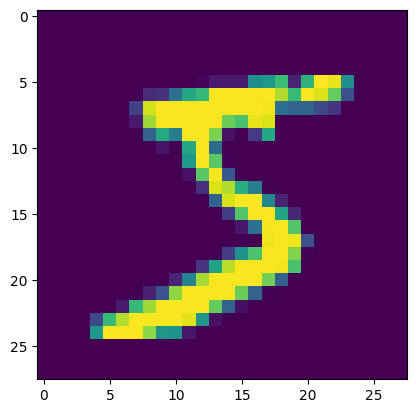

In [15]:
import matplotlib.pyplot as plt   # Library for displaying images and plotting graphs
plt.imshow(X_train[0])            # Shows first training image (digit 5) as a picture

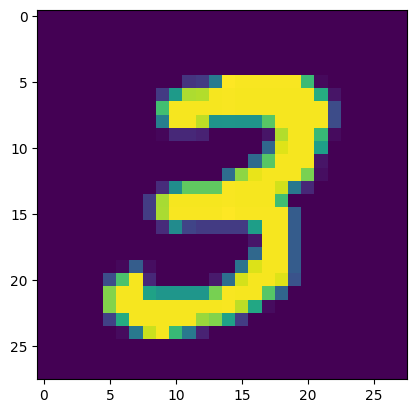

In [17]:
plt.imshow(X_train[7])   # Shows 8th training image (digit 3) as a picture

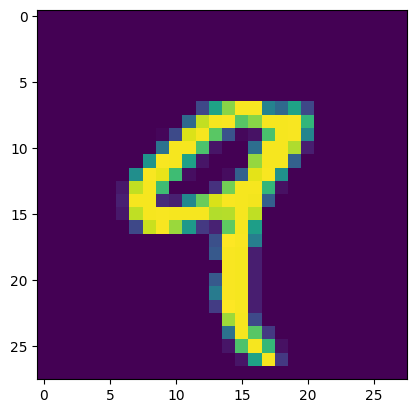

In [18]:
plt.imshow(X_train[4])   # Shows 5th training image (digit 9) as a picture

Load Data

In [26]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train.shape   # (60000, 28, 28) → 60k images 28x28 pixels
X_test.shape    # (10000, 28, 28) → 10k test images

(10000, 28, 28)

In [20]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

RESHAPE FOR CNN

In [27]:
# CNN needs 4D: (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1)   # 1 = grayscale channel
X_test = X_test.reshape(-1, 28, 28, 1)

X_train.shape   # (60000, 28, 28, 1)

(60000, 28, 28, 1)

NORMALIZE

In [28]:
X_train = X_train/255   # Without this, values are 0-255 (big numbers). Neural networks learn faster when values are 0-1
X_test = X_test/255     # Same for test data - must be consistent with training data

# Reason: Neural networks converge faster when pixel values are in 0-1 range instead of 0-255

In [29]:
X_train [0]  #is the 1st photograph so here we see all values arranged in between 0 to 1

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

BUILD CNN MODEL

In [30]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))  # 32 filters of size 3x3, ReLU activation, input is 28x28 grayscale image
model.add(MaxPooling2D((2,2)))  # Reduces size 28x28 → 14x14

model.add(Conv2D(64, (3,3), activation='relu'))  # 64 filters, finds shapes
model.add(MaxPooling2D((2,2)))  # Reduces 14x14 → 7x7

model.add(Conv2D(128, (3,3), activation='relu')) # 128 filters, finds patterns

model.add(Flatten())  # Converts 2D to 1D
model.add(Dense(128, activation='relu'))  # Fully connected layer
model.add(Dropout(0.5))  # Prevents overfitting
model.add(Dense(10, activation='softmax'))  # Output: 10 digits

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

# LAYER 1: Conv2D (32 filters)



*   Input:  28×28×1  (image)
*   Output: 26×26×32 (32 feature maps)
*   Params: 320

Explanation:
- 32 small filters (3×3 each) slide over image
- Each filter finds different patterns (edges, corners)
- 320 parameters = (3×3×1 + 1) × 32

# LAYER 2: MaxPooling2D

*   Input:  26×26×32
*   Output: 13×13×32
*   Params: 0

Explanation:
- Takes maximum value in each 2×2 block
- Reduces size by half (26→13)
- No learning, just downsampling
- Makes model faster and detects features anywhere

# LAYER 3: Conv2D (64 filters)

*   Input:  13×13×32
*   Output: 11×11×64
*   Params: 18,496

Explanation:
- 64 filters of size 3×3
- Finds more complex patterns (curves, shapes)
- 18,496 = (3×3×32 + 1) × 64


# LAYER 4: MaxPooling2D

Input:  11×11×64

Output: 5×5×64

Params: 0

Explanation:
- Another pooling layer
- Reduces 11×11 → 5×5
- Keeps important features

# LAYER 5: Conv2D (128 filters)

Input:  5×5×64

Output: 3×3×128

Params: 73,856

Explanation:
- 128 filters (most complex patterns)
- Detects complete digit parts
- 73,856 = (3×3×64 + 1) × 128

# LAYER 6: Flatten
Input:  3×3×128

Output: 1152 (one long vector)

Params: 0

Explanation:
- Converts 3D to 1D
- 3×3×128 = 1152 numbers in a line
- Prepares for dense layers


# LAYER 7: Dense (128 neurons)

Input:  1152

Output: 128

Params: 147,584

Explanation:
- Fully connected layer
- Each neuron connects to all 1152 inputs
- Learns combinations of features
- 147,584 = (1152×128) + 128

# LAYER 8: Dropout (0.5)

Input:  128

Output: 128

Params: 0

Explanation:
- Randomly turns off 50% of neurons during training
- Prevents overfitting
- Forces network to learn redundant patterns

# LAYER 9: Dense (10 neurons)

Input:  128

Output: 10

Params: 1,290

Explanation:
- Output layer
- 10 neurons = digits 0-9
- Softmax gives probabilities
- 1,290 = (128×10) + 10

# TOTAL PARAMETERS: 241,546

320 + 18,496 + 73,856 + 147,584 + 1,290 = 241,546



*   Image (28×28)
*   Conv2D (finds edges) → 26×26×32
*   MaxPool (reduces size) → 13×13×32
*   Conv2D (finds shapes) → 11×11×64
*   LMaxPool (reduces size) → 5×5×64
*   Conv2D (finds patterns) → 3×3×128
*   Flatten (make 1D) → 1152
*   Dense (learn patterns) → 128
*   Dropout (prevent overfitting) → 128
*   Dense (output digits) → 10



COMPILE

In [31]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

Train

In [32]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.9349 - loss: 0.2142 - val_accuracy: 0.9821 - val_loss: 0.0542
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.9814 - loss: 0.0648 - val_accuracy: 0.9872 - val_loss: 0.0433
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.9857 - loss: 0.0490 - val_accuracy: 0.9875 - val_loss: 0.0399
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9896 - loss: 0.0353 - val_accuracy: 0.9862 - val_loss: 0.0463
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9913 - loss: 0.0284 - val_accuracy: 0.9900 - val_loss: 0.0375
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.9921 - loss: 0.0243 - val_accuracy: 0.9901 - val_loss: 0.0453
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.9934 - loss: 0.0212 - val_accuracy: 0.9898 - val_loss: 0.0471
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.9945 -

PREDICT

In [33]:
y_prob = model.predict(X_test)   # Predicts probabilities (10 values per image) for all 10,000 test images
y_pred = y_prob.argmax(axis=1)   # Converts probabilities to digits: picks highest probability position (0-9) for each image

from sklearn.metrics import accuracy_score   # Imports function to calculate accuracy
accuracy_score(y_test, y_pred)   # Compares true labels vs predicted labels, returns percentage of correct predictions (CNN accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


0.9922

CONFUSION MATRIX

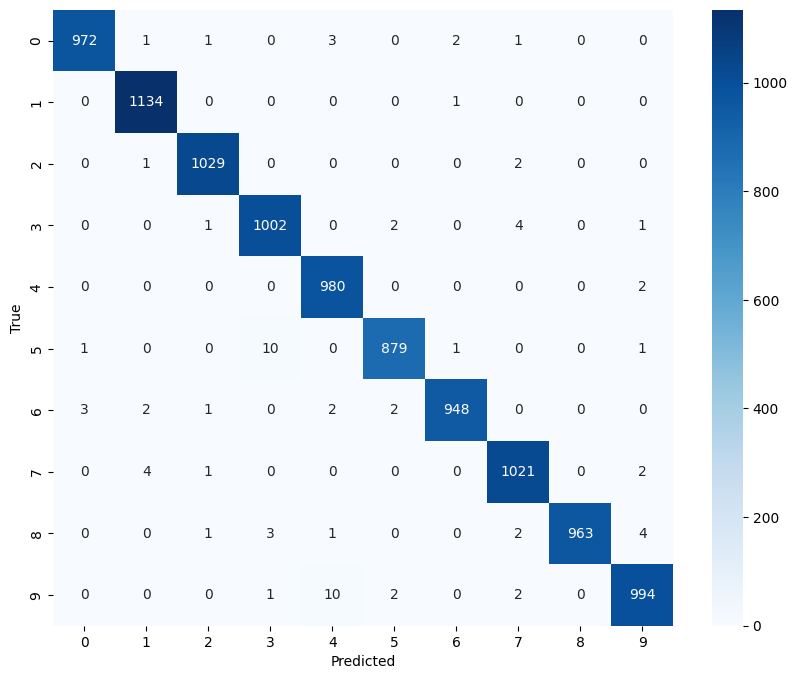

In [35]:
cm = confusion_matrix(y_test, y_pred)   # Creates table: rows=True digits, columns=Predicted digits, shows how many times each digit was confused
plt.figure(figsize=(10,8))              # Makes figure size 10 inches wide, 8 inches tall
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # Draws colored heatmap, annot=True shows numbers, fmt='d' shows integers, cmap='Blues' is blue color scheme
plt.xlabel('Predicted')                 # X-axis label (what model predicted)
plt.ylabel('True')                      # Y-axis label (what digit actually was)
plt.show()                              # Displays the confusion matrix

PER-CLASS ACCURACY

In [36]:
for digit in range(10):     # Loop through digits 0 to 9 one by one
    mask = (y_test == digit)    # Creates TRUE/FALSE list: True where image is this digit, False otherwise
    acc = (y_test[mask] == y_pred[mask]).sum() / mask.sum() * 100    # (Correct predictions ÷ Total images of this digit) × 100
    print(f"Digit {digit}: {acc:.2f}%")     # Prints accuracy for each digit (example: Digit 5: 97.50%)

Digit 0: 99.18%
Digit 1: 99.91%
Digit 2: 99.71%
Digit 3: 99.21%
Digit 4: 99.80%
Digit 5: 98.54%
Digit 6: 98.96%
Digit 7: 99.32%
Digit 8: 98.87%
Digit 9: 98.51%


 CLASSIFICATION REPORT

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      0.99      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



# precision = Of all images model predicted as this digit, how many were actually correct?
# recall = Of all actual images of this digit, how many did model correctly find?
# f1-score = Harmonic mean of precision and recall (balance between both)
# support = Number of test images actually having this digit (example: 980 images of digit 0 in test set)

PERCENTAGES EXPLANATION

In [47]:
print(f"Training: {history.history['accuracy'][-1]*100:.2f}%")     # Last epoch training accuracy (model learned from 48,000 images)
print(f"Validation: {history.history['val_accuracy'][-1]*100:.2f}%") # Last epoch validation accuracy (tested on 12,000 images during training)
print(f"Test: {accuracy_score(y_test, y_pred)*100:.2f}%")          # Final test accuracy (tested on 10,000 new images)

Training: 99.49%
Validation: 99.09%
Test: 99.22%


Wrong Prediction

In [49]:
wrong_count = (y_test != y_pred).sum()   # Counts total wrong predictions
print(f"Wrong predictions: {wrong_count} out of 10000 ({wrong_count/10000*100:.2f}%)")  # Shows errors

Wrong predictions: 78 out of 10000 (0.78%)


PLOT GRAPHS

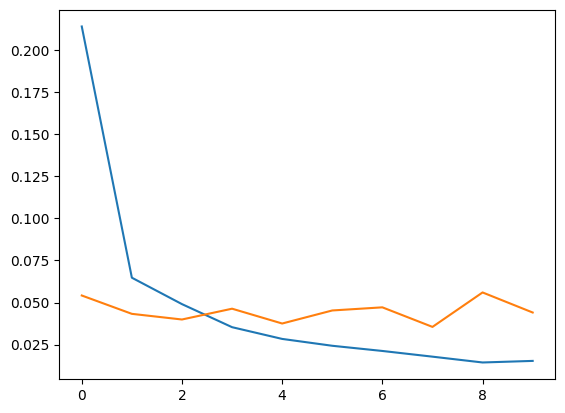

In [48]:
plt.plot(history.history['loss'])        # Plots training loss (error) decreasing over epochs
plt.plot(history.history['val_loss'])    # Plots validation loss (error on unseen data) over epochs

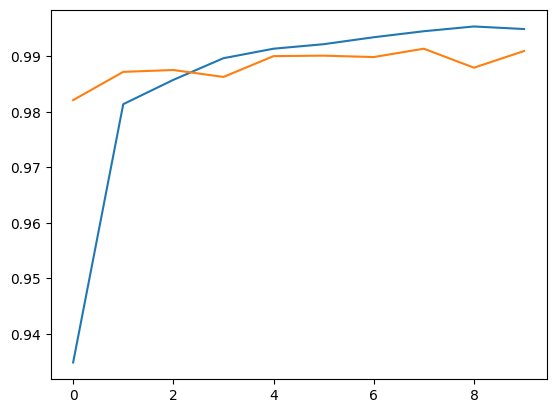

In [46]:
plt.plot(history.history['accuracy'])        # Plots training accuracy over epochs (how well model learned training data)
plt.plot(history.history['val_accuracy'])    # Plots validation accuracy over epochs (how well model performs on unseen validation data)
plt.show()                                   # Displays the accuracy graph

TEST SINGLE IMAGE

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


array([7])

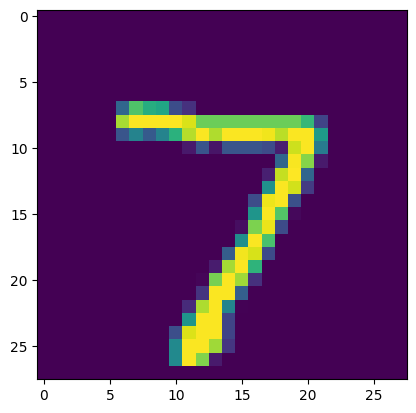

In [45]:
plt.imshow(X_test[0])   # Displays first test image (28x28 pixels) as picture to see what digit it is

model.predict(X_test[0].reshape(1,28,28,1)).argmax(axis=1)   # Predicts digit for single image: reshapes (28,28,1) to (1,28,28,1) for batch, then returns predicted digit (0-9)

Why CNN is better for images:

Same digit written differently:


ANN sees: different pixel positions → different numbers → confused
CNN sees: both are "circle shape" → same pattern → correct!

Accuracy Difference:

ANN: ~97-98% (misses some because shape changed)

CNN: ~99%+ (catches pattern even if position changes)

